In [2]:
import pandas as pd
import numpy as np

# 1. Carregamento dos dados
df = pd.read_csv(r'C:\Users\nicol\Desktop\Trabalho Big Data N2\trabalho_bigdata\data\consulta (3).csv', sep=';', encoding='latin1')
anos_cols = [str(ano) for ano in range(2000, 2025)]

# Função de limpeza para converter o padrão brasileiro (1.234.567) para float
def limpar_valor(valor):
    if pd.isna(valor) or str(valor).strip() == '-': return 0.0
    res = str(valor).replace('.', '').strip()
    try: return float(res)
    except: return 0.0

for col in anos_cols:
    df[col] = df[col].apply(limpar_valor)

# 2. Processamento das Estatísticas (Foco em Quantidade Produzida)
df_prod = df[df['Variável'].str.contains("Quantidade Produzida", case=False)].copy()
resultados = []

for _, row in df_prod.iterrows():
    # Extrai o nome da cultura (ex: Soja, Milho)
    partes = row['Variável'].split(' - ')
    cultura = partes[1].strip() if len(partes) > 1 else row['Variável']

    dados = row[anos_cols].values.astype(float)
    serie = pd.Series(dados)

    # Cálculo da Moda com a correção
    moda_result = serie.mode()
    valor_moda = float(moda_result.iloc[0]) if not moda_result.empty else 0.0


    resultados.append({
        'Cultura': cultura,
        'Máximo': float(np.max(dados)),
        'Mínimo': float(np.min(dados)),
        'Média': float(np.mean(dados)),
        'Mediana': float(np.median(dados)),
        'Moda': valor_moda,
        'Desvio Padrão': float(np.std(dados)),
        'Variância': float(np.var(dados)),
        'Q1': float(np.percentile(dados, 25)),
        'Q3': float(np.percentile(dados, 75))
    })

# 3. Ordenação por Produção Máxima
df_stats = pd.DataFrame(resultados).sort_values(by='Máximo', ascending=False)

# 4. Impressão do Relatório Final
print("\n" + "="*140)
print(f"{'RELATÓRIO ESTATÍSTICO COMPLETO (R1) - AGRONEGÓCIO GOIÁS':^140}")
print("="*140)
headers = f"{'Cultura':<20} | {'Máximo (t)':>12} | {'Mínimo (t)':>12} | {'Média (t)':>12} | {'Mediana (t)':>12} | {'Moda (t)':>12} | {'Desvio P.':>12}"
print(headers)
print("-" * 140)

for _, r in df_stats.iterrows():
    print(f"{r['Cultura']:<20} | {r['Máximo']:>12,.0f} | {r['Mínimo']:>12,.0f} | {r['Média']:>12,.0f} | {r['Mediana']:>12,.0f} | {r['Moda']:>12,.0f} | {r['Desvio Padrão']:>12,.0f}")

print("="*140)


                                          RELATÓRIO ESTATÍSTICO COMPLETO (R1) - AGRONEGÓCIO GOIÁS                                           
Cultura              |   Máximo (t) |   Mínimo (t) |    Média (t) |  Mediana (t) |     Moda (t) |    Desvio P.
--------------------------------------------------------------------------------------------------------------------------------------------
Cana-de-açúcar       |   81,599,588 |   10,162,959 |   49,767,190 |   58,348,797 |   10,162,959 |   26,686,656
Soja                 |   17,405,060 |    4,052,169 |    9,132,109 |    8,398,891 |    4,052,169 |    3,694,891
Milho                |   14,460,846 |    2,855,538 |    7,256,741 |    5,804,842 |    2,855,538 |    3,472,739
Sorgo                |    1,513,332 |      238,545 |      795,242 |      813,944 |      238,545 |      332,987
Tomate               |    1,463,461 |      712,448 |    1,073,015 |    1,055,337 |      712,448 |      225,689
Algodão Herbáceo     |      469,794 |       86,446 

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações para melhorar a visualização dos gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

#### **Gráfico 1: Produção Máxima por Cultura (Top 10)**

Este gráfico de barras mostra as 10 culturas com a maior produção máxima registrada, permitindo identificar as culturas de maior pico de produção em Goiás.

C:\Users\nicol\AppData\Local\Temp\ipykernel_23840\600753292.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Máximo', y='Cultura', data=df_top10_max, palette='viridis')


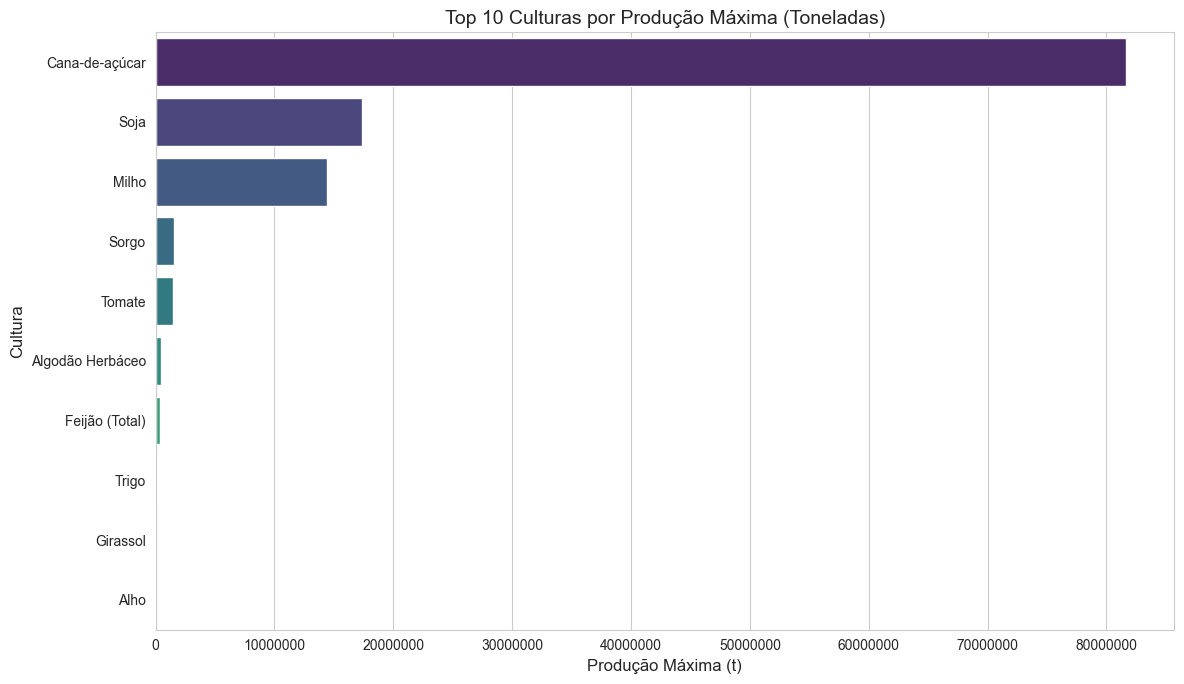

In [4]:
# O DataFrame df_stats já está ordenado por 'Máximo' de forma decrescente
df_top10_max = df_stats.head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x='Máximo', y='Cultura', data=df_top10_max, palette='viridis')
plt.title('Top 10 Culturas por Produção Máxima (Toneladas)')
plt.xlabel('Produção Máxima (t)')
plt.ylabel('Cultura')
plt.ticklabel_format(style='plain', axis='x') # Remove notação científica
plt.tight_layout()
plt.show()

#### **Gráfico 2: Produção Média por Cultura (Top 10)**

Este gráfico apresenta as 10 culturas com a maior média de produção, indicando a produção típica ao longo dos anos para cada cultura.

C:\Users\nicol\AppData\Local\Temp\ipykernel_23840\3194715928.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Média', y='Cultura', data=df_top10_mean, palette='magma')


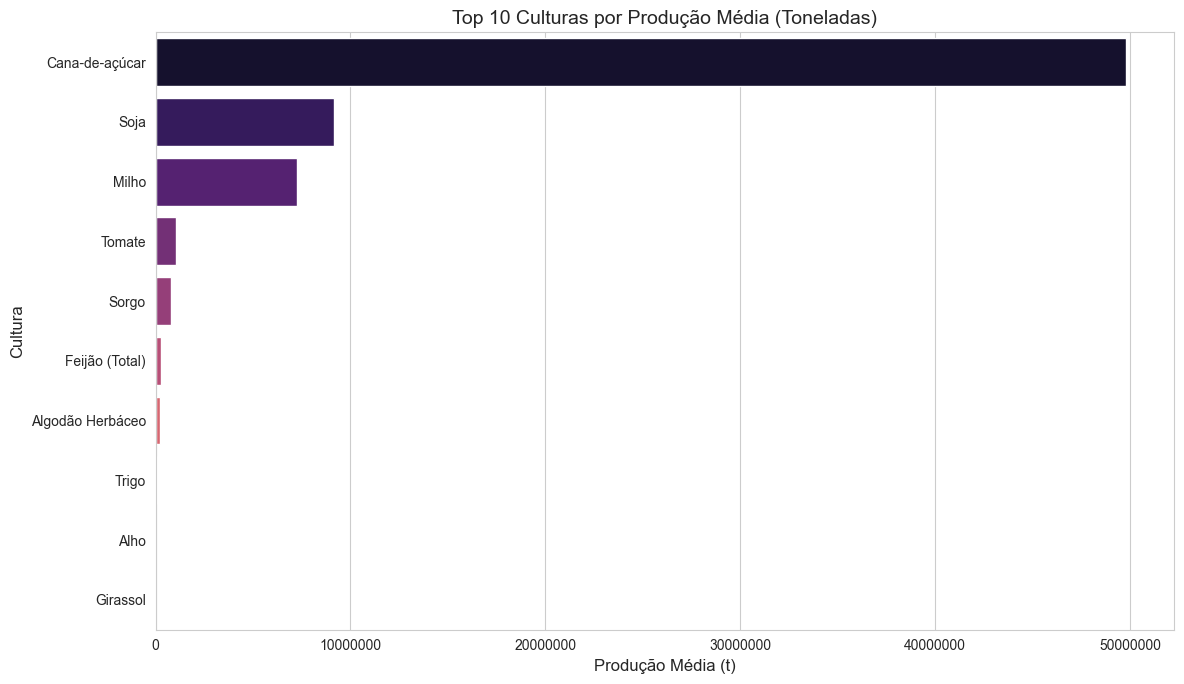

In [5]:
# Ordena o DataFrame por 'Média' para pegar as top 10 culturas com maior média
df_top10_mean = df_stats.sort_values(by='Média', ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x='Média', y='Cultura', data=df_top10_mean, palette='magma')
plt.title('Top 10 Culturas por Produção Média (Toneladas)')
plt.xlabel('Produção Média (t)')
plt.ylabel('Cultura')
plt.ticklabel_format(style='plain', axis='x') # Remove notação científica
plt.tight_layout()
plt.show()

#### **Gráfico 3: Desvio Padrão da Produção por Cultura (Top 10)**

Este gráfico ilustra o desvio padrão da produção para as 10 culturas com maior variabilidade, mostrando quais culturas têm a produção mais inconsistente ao longo do tempo.

C:\Users\nicol\AppData\Local\Temp\ipykernel_23840\767813852.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Desvio Padrão', y='Cultura', data=df_top10_std, palette='cividis')


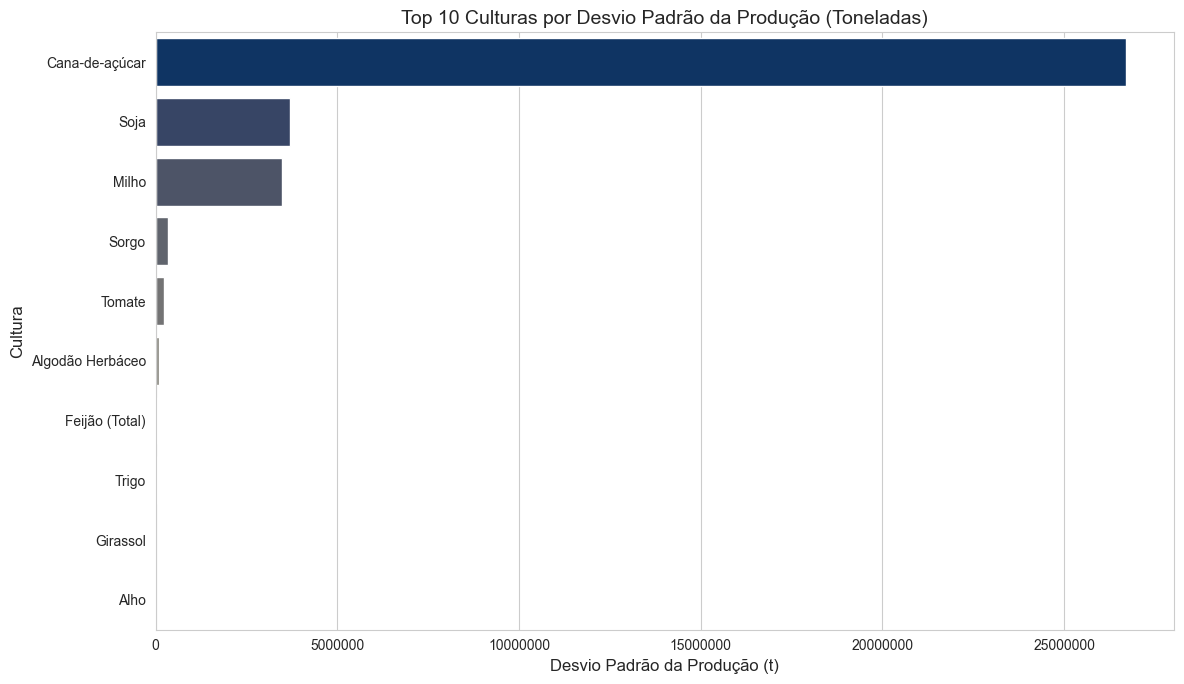

In [6]:
# Ordena o DataFrame por 'Desvio Padrão' para pegar as top 10 culturas com maior variabilidade
df_top10_std = df_stats.sort_values(by='Desvio Padrão', ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x='Desvio Padrão', y='Cultura', data=df_top10_std, palette='cividis')
plt.title('Top 10 Culturas por Desvio Padrão da Produção (Toneladas)')
plt.xlabel('Desvio Padrão da Produção (t)')
plt.ylabel('Cultura')
plt.ticklabel_format(style='plain', axis='x') # Remove notação científica
plt.tight_layout()
plt.show()

## Visualizações dos Dados

Aqui estão os gráficos gerados para análise das estatísticas de produção agrícola:

### Configuração do Ambiente de Visualização
```python
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações para melhorar a visualização dos gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
```

### Gráfico 1: Produção Máxima por Cultura (Top 10)

Este gráfico de barras mostra as 10 culturas com a maior produção máxima registrada, permitindo identificar as culturas de maior pico de produção em Goiás.

```python
# O DataFrame df_stats já está ordenado por 'Máximo' de forma decrescente
df_top10_max = df_stats.head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x='Máximo', y='Cultura', data=df_top10_max, palette='viridis')
plt.title('Top 10 Culturas por Produção Máxima (Toneladas)')
plt.xlabel('Produção Máxima (t)')
plt.ylabel('Cultura')
plt.ticklabel_format(style='plain', axis='x') # Remove notação científica
plt.tight_layout()
plt.show()
```

### Gráfico 2: Produção Média por Cultura (Top 10)

Este gráfico apresenta as 10 culturas com a maior média de produção, indicando a produção típica ao longo dos anos para cada cultura.

```python
# Ordena o DataFrame por 'Média' para pegar as top 10 culturas com maior média
df_top10_mean = df_stats.sort_values(by='Média', ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x='Média', y='Cultura', data=df_top10_mean, palette='magma')
plt.title('Top 10 Culturas por Produção Média (Toneladas)')
plt.xlabel('Produção Média (t)')
plt.ylabel('Cultura')
plt.ticklabel_format(style='plain', axis='x') # Remove notação científica
plt.tight_layout()
plt.show()
```

### Gráfico 3: Desvio Padrão da Produção por Cultura (Top 10)

Este gráfico ilustra o desvio padrão da produção para as 10 culturas com maior variabilidade, mostrando quais culturas têm a produção mais inconsistente ao longo do tempo.

```python
# Ordena o DataFrame por 'Desvio Padrão' para pegar as top 10 culturas com maior variabilidade
df_top10_std = df_stats.sort_values(by='Desvio Padrão', ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x='Desvio Padrão', y='Cultura', data=df_top10_std, palette='cividis')
plt.title('Top 10 Culturas por Desvio Padrão da Produção (Toneladas)')
plt.xlabel('Desvio Padrão da Produção (t)')
plt.ylabel('Cultura')
plt.ticklabel_format(style='plain', axis='x') # Remove notação científica
plt.tight_layout()
plt.show()
```



MÉTRICAS DE AVALIAÇÃO (R3) - RANDOM FOREST: ALGODÃO HERBÁCEO
MAE (Erro Médio Absoluto):      9,175.23 toneladas
RMSE (Erro Quadrático Médio):   11,503.07 toneladas
R² Score (Coef. Determinação):  0.1531


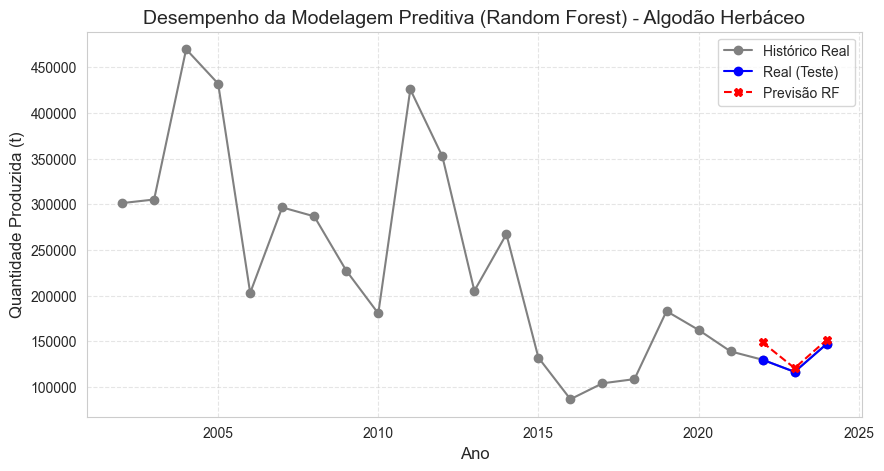

In [7]:
# ==============================================================================
# PARTE R3 - MODELAGEM PREDITIVA COM RANDOM FOREST E PROPHET
# ==============================================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Definição da cultura alvo (pode alterar para "Algodão" se quiser)
cultura_alvo = "Algodão Herbáceo"
df_alvo = df_prod[df_prod['Variável'].str.contains(cultura_alvo, case=False)].copy()

# 2. Transformação do formato de colunas (anos) para linhas (série temporal)
df_ml = df_alvo.melt(id_vars=['Localidade', 'Variável'], value_vars=anos_cols,
                     var_name='Ano', value_name='Producao')

df_ml['Ano'] = df_ml['Ano'].astype(int)
df_ml = df_ml.sort_values('Ano').reset_index(drop=True)

# 3. Engenharia de Atributos (Criação do Lag: produção do ano anterior)
df_ml['Producao_Ano_Anterior'] = df_ml['Producao'].shift(1)
df_ml['Media_2_Anos'] = df_ml['Producao'].rolling(window=2).mean()
df_ml['Producao_2_Anos_Atras'] = df_ml['Producao'].shift(2)
df_ml = df_ml.dropna()

# 4. Divisão temporal em Treino (2000 até 2021) e Teste (2022 até 2024)
df_treino = df_ml[df_ml['Ano'] <= 2021]
df_teste = df_ml[df_ml['Ano'] > 2021]

colunas_features = ['Ano', 'Producao_Ano_Anterior', 'Media_2_Anos', 'Producao_2_Anos_Atras']

X_treino = df_treino[colunas_features]
y_treino = df_treino['Producao']

X_teste = df_teste[colunas_features]
y_teste = df_teste['Producao']

# 5. Treinamento do Random Forest
# JUSTIFICATIVA DO ALGORITMO: Escolhido por ser um método ensemble baseado em múltiplas
# árvores de decisão. É robusto para lidar com variações não lineares em séries temporais
# agrícolas curtas, reduzindo a variância e mitigando o risco de overfitting.
modelo_rf = RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_split=3,random_state=42)
modelo_rf.fit(X_treino, y_treino)

# 6. Previsões e Métricas de Teste
previsoes = modelo_rf.predict(X_teste)

mae = mean_absolute_error(y_teste, previsoes)
rmse = np.sqrt(mean_squared_error(y_teste, previsoes))
r2 = r2_score(y_teste, previsoes)

# Impressão dos resultados para o relatório
print("\n" + "="*80)
print(f"MÉTRICAS DE AVALIAÇÃO (R3) - RANDOM FOREST: {cultura_alvo.upper()}")
print("="*80)
print(f"MAE (Erro Médio Absoluto):      {mae:,.2f} toneladas")
print(f"RMSE (Erro Quadrático Médio):   {rmse:,.2f} toneladas")
print(f"R² Score (Coef. Determinação):  {r2:.4f}")
print("="*80)

# 7. Gráfico Comparativo (Real vs Previsto)
plt.figure(figsize=(10, 5))
plt.plot(df_ml['Ano'], df_ml['Producao'], label='Histórico Real', marker='o', color='gray')
plt.plot(df_teste['Ano'], y_teste, label='Real (Teste)', marker='o', color='blue')
plt.plot(df_teste['Ano'], previsoes, label='Previsão RF', marker='X', color='red', linestyle='--')
plt.title(f'Desempenho da Modelagem Preditiva (Random Forest) - {cultura_alvo}')
plt.xlabel('Ano')
plt.ylabel('Quantidade Produzida (t)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


RELATÓRIO DE MODELAGEM - ALGODÃO HERBÁCEO
IMPORTÂNCIA DAS VARIÁVEIS:
- Ano          : 2.48%
- Lag_Producao : 3.44%
- Area         : 94.08%

MÉTRICAS DE AVALIAÇÃO:
- MAE (Erro Médio Absoluto):    7,146.63 t
- RMSE (Erro Quadrático Médio): 9,072.96 t
- R² Score:                    0.4731


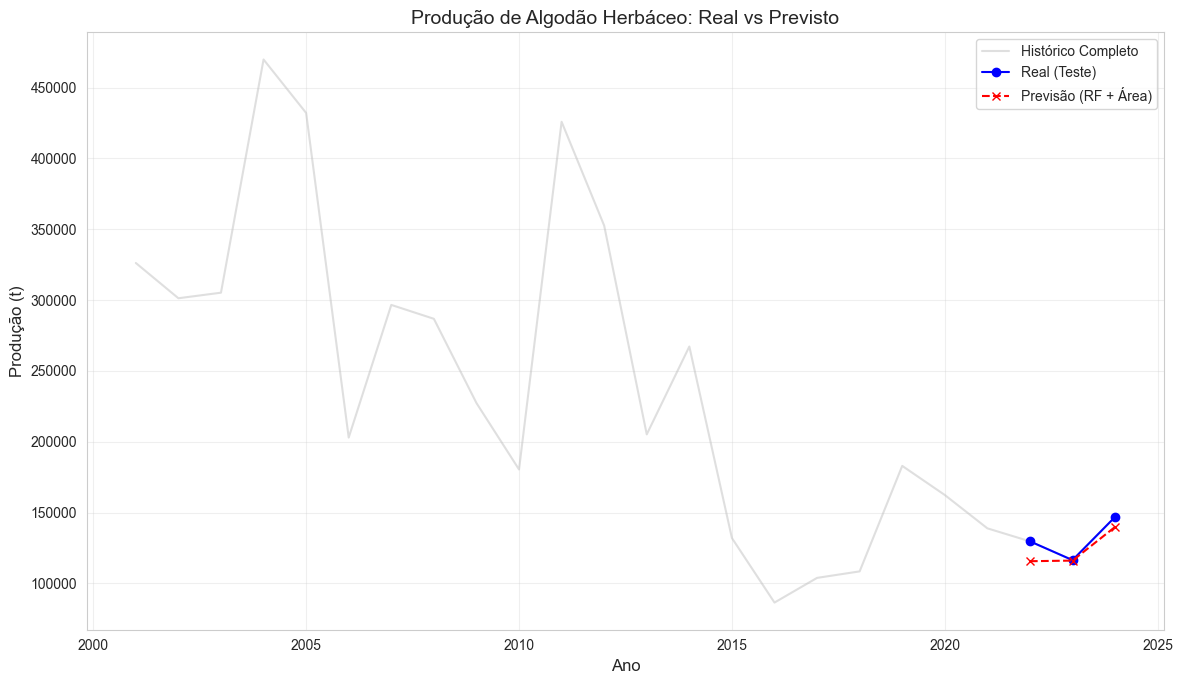

In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==============================================================================
# PREDIÇÃO COM RANDOM FOREST UTILISANDO A ÁREA PRODUSIDA COMO ATRIBUTA PARA MELHORAR A PRECISÃO DA PREDIÇÃO
# ==============================================================================

# 1. Data Wrangling: Alinhamento de Produção e Área
cultura_alvo = "Algodão Herbáceo"

# Filtramos as duas variáveis necessárias no DataFrame original
df_prod_base = df[df["Variável"].str.contains(cultura_alvo) & df["Variável"].str.contains("Quantidade Produzida")].copy()
df_area_base = df[df["Variável"].str.contains(cultura_alvo) & df["Variável"].str.contains("Área Colhida")].copy()

# Melt para formato longo
df_prod_long = df_prod_base.melt(id_vars=["Localidade"], value_vars=anos_cols, var_name="Ano", value_name="Producao")
df_area_long = df_area_base.melt(id_vars=["Localidade"], value_vars=anos_cols, var_name="Ano", value_name="Area")

# Merge das duas tabelas pelo Ano
df_final = pd.merge(df_prod_long, df_area_long, on=["Localidade", "Ano"])
df_final["Ano"] = df_final["Ano"].astype(int)
df_final = df_final.sort_values("Ano")

# 2. Engenharia de Atributos
df_final["Lag_Producao"] = df_final["Producao"].shift(1)
df_final = df_final.dropna() # Remove 2000 que ficou sem lag

# 3. Divisão de Dados (Até 2021 Treino, 2022+ Teste)
df_treino = df_final[df_final["Ano"] <= 2021]
df_teste = df_final[df_final["Ano"] >= 2022]

# Features: Agora incluímos a "Area"
features = ["Ano", "Lag_Producao", "Area"]
X_train = df_treino[features]
y_train = df_treino["Producao"]
X_test = df_teste[features]
y_test = df_teste["Producao"]

# 4. Treinamento do Modelo
model_rf = RandomForestRegressor(n_estimators=200, random_state=42)
model_rf.fit(X_train, y_train)

# 5. Avaliação e Importância das Variáveis
preds = model_rf.predict(X_test)
importancias = model_rf.feature_importances_

# Cálculo das métricas
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"\n{'='*60}")
print(f"RELATÓRIO DE MODELAGEM - {cultura_alvo.upper()}")
print(f"{'='*60}")
print("IMPORTÂNCIA DAS VARIÁVEIS:")
for feat, imp in zip(features, importancias):
    print(f"- {feat:<13}: {imp:.2%}")
print(f"\nMÉTRICAS DE AVALIAÇÃO:")
print(f"- MAE (Erro Médio Absoluto):    {mae:,.2f} t")
print(f"- RMSE (Erro Quadrático Médio): {rmse:,.2f} t")
print(f"- R² Score:                    {r2:.4f}")
print(f"{'='*60}")

# 6. Visualização
plt.figure(figsize=(12, 7))
plt.plot(df_final["Ano"], df_final["Producao"], color="silver", label="Histórico Completo", alpha=0.5)
plt.plot(df_teste["Ano"], y_test, "bo-", label="Real (Teste)")
plt.plot(df_teste["Ano"], preds, "rx--", label="Previsão (RF + Área)")

plt.title(f"Produção de {cultura_alvo}: Real vs Previsto")
plt.xlabel("Ano")
plt.ylabel("Produção (t)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

03:10:31 - cmdstanpy - INFO - Chain [1] start processing
03:10:33 - cmdstanpy - INFO - Chain [1] done processing



RELATÓRIO PREDITIVO (PROPHET): ALGODÃO HERBÁCEO
MAE (Erro Médio Absoluto):    22,048.81 t
RMSE (Erro Quadrático Médio): 27,929.90 t


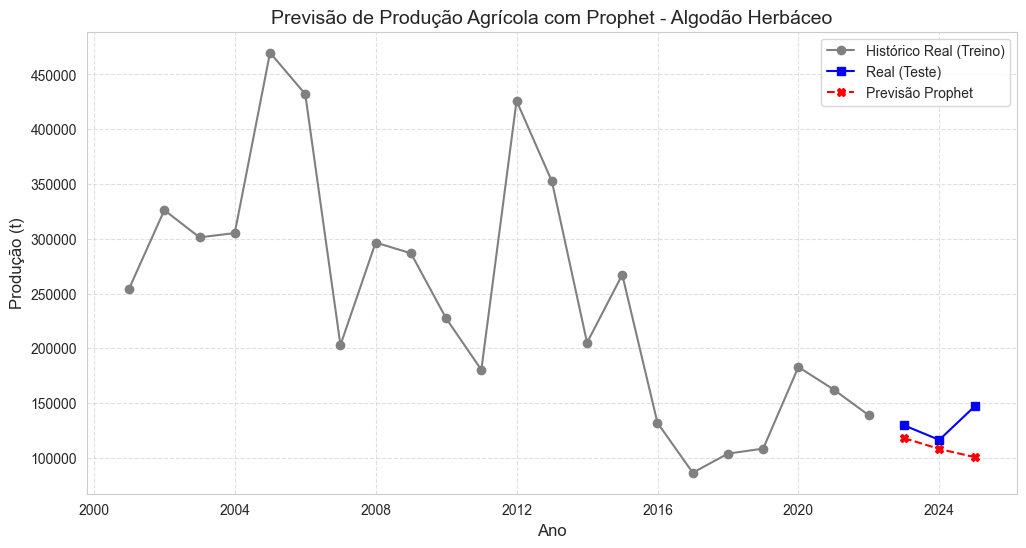

In [9]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# PREDIÇÃO COM PROPHET PARA TENTAR CHEGAR EM UM RESULTADO MELHOR
# ==============================================================================

# 1. Definição da cultura alvo (ex: 'Trigo', 'Soja', 'Cana-de-açúcar')
cultura_alvo_prp = 'Algodão Herbáceo'
df_alvo_prp = df_prod[df_prod['Variável'].str.contains(cultura_alvo_prp, case=False)].copy()

# 2. Transformação (Melt): Colunas de anos para linhas
df_melt_prp = df_alvo_prp.melt(id_vars=['Localidade', 'Variável'], value_vars=anos_cols,
                       var_name='Ano', value_name='Producao')

# Converter o ano para datetime (padrão Prophet: YYYY-MM-DD)
# Assumindo o último dia do ano para representar a safra anual
df_melt_prp['ds'] = pd.to_datetime(df_melt_prp['Ano'] + '-12-31')
df_melt_prp['y'] = df_melt_prp['Producao'].astype(float)

# 3. Divisão de Dados: Treino (<= 2021) e Teste (>= 2022)
df_treino_prp = df_melt_prp[df_melt_prp['ds'].dt.year <= 2021][['ds', 'y']]
df_teste_prp = df_melt_prp[df_melt_prp['ds'].dt.year >= 2022][['ds', 'y']]

# 4. Modelagem com Prophet
# Instanciando o modelo
modelo_prophet_prp = Prophet(yearly_seasonality=True, daily_seasonality=False, weekly_seasonality=False)

# Ajuste aos dados de treino
modelo_prophet_prp.fit(df_treino_prp)

# Criando dataframe futuro para o período de teste (3 anos à frente)
future_prp = modelo_prophet_prp.make_future_dataframe(periods=3, freq='YE')

# Realizando a previsão
forecast_prp = modelo_prophet_prp.predict(future_prp)

# Extrair apenas as previsões correspondentes ao período de teste
previsoes_prp = forecast_prp[forecast_prp['ds'].dt.year >= 2022][['ds', 'yhat']]

# 5. Cálculo de Métricas (MAE e RMSE)
# Unir previsões com dados reais de teste para cálculo
df_eval_prp = df_teste_prp.merge(previsoes_prp, on='ds')

mae_prophet_prp = mean_absolute_error(df_eval_prp['y'], df_eval_prp['yhat'])
rmse_prophet_prp = np.sqrt(mean_squared_error(df_eval_prp['y'], df_eval_prp['yhat']))

print(f"\n{'='*60}")
print(f"RELATÓRIO PREDITIVO (PROPHET): {cultura_alvo_prp.upper()}")
print(f"{'='*60}")
print(f"MAE (Erro Médio Absoluto):    {mae_prophet_prp:,.2f} t")
print(f"RMSE (Erro Quadrático Médio): {rmse_prophet_prp:,.2f} t")
print(f"{'='*60}")

# 6. Gráfico Comparativo
plt.figure(figsize=(12, 6))

# Histórico Real (Treino)
plt.plot(df_treino_prp['ds'], df_treino_prp['y'], label='Histórico Real (Treino)', color='gray', marker='o')

# Realidade do Período de Teste
plt.plot(df_teste_prp['ds'], df_teste_prp['y'], label='Real (Teste)', color='blue', marker='s')

# Previsão do Prophet
plt.plot(df_eval_prp['ds'], df_eval_prp['yhat'], label='Previsão Prophet', color='red', linestyle='--', marker='X')

plt.title(f'Previsão de Produção Agrícola com Prophet - {cultura_alvo_prp}')
plt.xlabel('Ano')
plt.ylabel('Produção (t)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()